5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

        zero       0.87      1.00      0.93        13
         one       1.00      0.81      0.90        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.56      0.71         9
        five       0.91      0.91      0.91        23
         six       1.00      0.64      0.78        11
       seven       0.73      1.00      0.84        16
       eight       0.94      0.94      0.94        16
        nine       0.89      0.96      0.92        25

    accuracy                           0.90       160
   macro avg       0.92      0.87      0.88       160
weighted avg       0.91      0.90      0.90       160



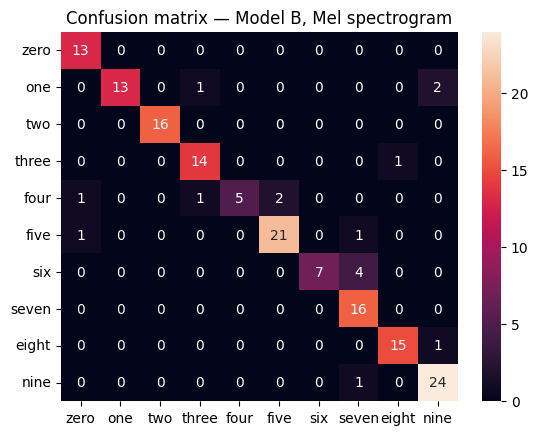

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR, DATA_DIR


model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "deep_model-melSpectrogram.keras"))

digits = ['zero','one','two','three','four','five','six','seven','eight','nine']


X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))


test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("confusion_matrix.png")


print(classification_report(y_true, y_pred, target_names=digits))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

        zero       1.00      1.00      1.00        13
         one       1.00      0.94      0.97        16
         two       1.00      1.00      1.00        16
       three       0.88      0.93      0.90        15
        four       1.00      0.78      0.88         9
        five       1.00      0.96      0.98        23
         six       1.00      1.00      1.00        11
       seven       1.00      1.00      1.00        16
       eight       0.88      0.94      0.91        16
        nine       0.96      0.96      0.96        25
     silence       0.99      1.00      1.00       257

    accuracy                           0.98       417
   macro avg       0.97      0.95      0.96       417
weighted avg       0.98      0.98      0.98       417



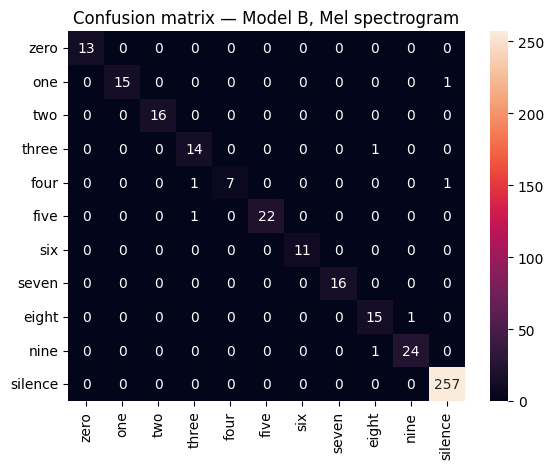

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(".."))
from config import MODEL_DIR, DATA_DIR


model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "best_baselineModel_augmented.keras"))

digits = ['zero','one','two','three','four','five','six','seven','eight','nine', 'silence']


X_test_mel = np.load(os.path.join(DATA_DIR, "X_test_mel_11class.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_11class.npy"))


test_ds = tf.data.Dataset.from_tensor_slices((X_test_mel, y_test)).batch(32)

y_pred = model.predict(test_ds).argmax(axis=1)
y_true = [label for _, label in test_ds.unbatch()]


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=digits, yticklabels=digits)
plt.title("Confusion matrix — Model B, Mel spectrogram")
plt.savefig("augmentedModel_confusion_matrix.png")


print(classification_report(y_true, y_pred, target_names=digits))


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

/Users/nicolas/Documents/GitHub/DAT255-Project-V26-Gr30/speech_env/lib/python3.13/site-packages/transformers/audio_utils.py:538: UserWarning: At least one mel filter has all zero values. The value for `num_mel_filters` (128) may be set too high. Or, the value for `num_frequency_bins` (257) may be set too low.
  warnings.warn(


=== AST Transformer (pretrained, digits only) ===
              precision    recall  f1-score   support

        zero       1.00      1.00      1.00        13
         one       1.00      0.94      0.97        16
         two       1.00      1.00      1.00        16
       three       1.00      1.00      1.00        15
        four       1.00      1.00      1.00         9
        five       1.00      1.00      1.00        23
         six       1.00      1.00      1.00        11
       seven       1.00      1.00      1.00        16
       eight       1.00      1.00      1.00        16
        nine       1.00      1.00      1.00        25

   micro avg       1.00      0.99      1.00       160
   macro avg       1.00      0.99      1.00       160
weighted avg       1.00      0.99      1.00       160

Time: 20.7 ms per sample


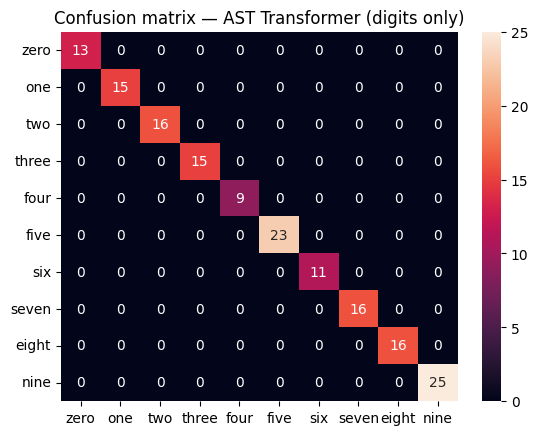

In [24]:
from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

dataset = load_dataset("google/speech_commands", "v0.01")
label_names = dataset["test"].features["label"].names

DIGIT_LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine']
digit_ids = {label_names.index(d) for d in DIGIT_LABELS if d in label_names}
label_to_idx = {d: i for i, d in enumerate(DIGIT_LABELS)}

# Only digit samples — AST has no silence class
test_digits = dataset["test"].filter(lambda x: x["label"] in digit_ids)

classifier = pipeline("audio-classification", model="MIT/ast-finetuned-speech-commands-v2")

y_true, y_pred_ast = [], []
start = time.time()

for sample in test_digits:
    audio = np.array(sample["audio"]["array"], dtype=np.float32)
    true_label = label_names[sample["label"]]
    pred_label = classifier(audio, sampling_rate=16000)[0]["label"]
    y_true.append(label_to_idx[true_label])
    y_pred_ast.append(label_to_idx.get(pred_label, -1))  # -1 for non-digit predictions

elapsed = time.time() - start

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_ast, labels=list(range(10)))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=DIGIT_LABELS, yticklabels=DIGIT_LABELS)
plt.title("Confusion matrix — AST Transformer (digits only)")
plt.savefig("ast_confusion_matrix.png")

print("=== AST Transformer (pretrained, digits only) ===")
print(classification_report(y_true, y_pred_ast, labels=list(range(10)), target_names=DIGIT_LABELS, zero_division=0))
print(f"Time: {elapsed / len(test_digits) * 1000:.1f} ms per sample")
